In [1]:
import sys
sys.path.insert(1, '../utils/')

In [2]:
import datacube
import time

from IPython.display import HTML, display

from utils.deafrica_plotting import rgb
from utils.nostra_dc import get_product_bbox
from utils.nostra_mapping import bbox_to_polygon, display_crosshair, get_utm_epsg_code, MapHandler
from utils.nostra_tools import style_output_cells

In [3]:
dc = datacube.Datacube(app="Test_MinIO_indexation")

In [4]:
# Check if default bbox is contained within the datacube
# and allow user to draw bbox if not.

product = 'ls89_c2l2_sp_local'

product_bbox = get_product_bbox(dc, product, split_size=10, stability_threshold=4)

In [5]:
# Create an instance of MapHandler
map_handler = MapHandler()
m, drc = map_handler.create_map(vect=[bbox_to_polygon(product_bbox)],
                               draw_rect=True)
display(m)

# append crosshair
time.sleep(2)  # make sure m is fully displayed
display_crosshair()

Map(center=[46.016623614450374, 6.644603170482554], controls=(AttributionControl(options=['position', 'prefix'…

<IPython.core.display.Javascript object>

In [6]:
# Warn in case of full AoI
aoi_poly = map_handler.aoi_tupple

if aoi_poly is None:
    style_output_cells('salmon', border_color='red', border_width='2px')
    print('The area of interest polygon (aoi_poly) has not been created. Please draw it in the previous cell.')
else:
    # A polygon was drawn
    style_output_cells()
    print('Custom area of interest polygon has been created.')

Custom area of interest polygon has been created.


In [7]:
# get EPSG code for the center of the AoI

epsg_code = get_utm_epsg_code((aoi_poly[1] + aoi_poly[3]) / 2, (aoi_poly[0] + aoi_poly[2]) / 2)

In [8]:
dss = dc.find_datasets(product=product,
                       x=(aoi_poly[0], aoi_poly[2]),
                       y=(aoi_poly[1], aoi_poly[3]))
times = [ds.time.begin for ds in dss]
start_date = min(times)
end_date = max(times)

In [9]:
lazy_ds = dc.load(product=product,
                  measurements=['red', 'green', 'blue'],
                  output_crs=f"EPSG:{epsg_code}",
                  y=(aoi_poly[1], aoi_poly[3]),
                  x=(aoi_poly[0], aoi_poly[2]),
                  time=(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')),
                  resolution=30,
                  group_by="solar_day",
                  dask_chunks={},
                  )

In [10]:
# 1. Search for the datasets using the same query parameters
datasets = dc.find_datasets(
    product=product,
    y=(aoi_poly[1], aoi_poly[3]),
    x=(aoi_poly[0], aoi_poly[2]),
    time=(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d'))
)

# 2. Extract the URIs (URLs) from each dataset
# Note: A dataset usually has one URI for the metadata and paths to the bands
all_urls = []
for ds in datasets:
    # This gives you the primary location/metadata URL
    all_urls.extend(ds.uris)
    
    # If you need the specific paths for 'red', 'green', 'blue' specifically:
    for band in ['red', 'green', 'blue']:
        band_path = ds.measurements.get(band, {}).get('path')
        if band_path:
            all_urls.append(band_path)

print(f"Found {len(datasets)} datasets.")
print(all_urls[:5]) # Show first 5

Found 4 datasets.
['file:///local_data/landsat-c2/level-2/standard/oli-tirs/2024/195/028/LC08_L2SP_195028_20240721_20240723_02_T1/ls89_c2l2_sp_local-metadata.yaml', '/local_data/landsat-c2/level-2/standard/oli-tirs/2024/195/028/LC08_L2SP_195028_20240721_20240723_02_T1/LC08_L2SP_195028_20240721_20240723_02_T1_SR_B4.TIF', '/local_data/landsat-c2/level-2/standard/oli-tirs/2024/195/028/LC08_L2SP_195028_20240721_20240723_02_T1/LC08_L2SP_195028_20240721_20240723_02_T1_SR_B3.TIF', '/local_data/landsat-c2/level-2/standard/oli-tirs/2024/195/028/LC08_L2SP_195028_20240721_20240723_02_T1/LC08_L2SP_195028_20240721_20240723_02_T1_SR_B2.TIF', 'file:///local_data/landsat-c2/level-2/standard/oli-tirs/2024/195/028/LC09_L2SP_195028_20240729_20240730_02_T1/ls89_c2l2_sp_local-metadata.yaml']


/tmp/ipykernel_787/2224904018.py:14: ODC2DeprecationWarning: Call to deprecated function (or staticmethod) uris. (Multiple locations are now deprecated. Please use the 'uri' attribute instead.)
-- Deprecated since version 1.9.0.
  all_urls.extend(ds.uris)


In [13]:
import datacube
dc = datacube.Datacube()
ds = dc.index.datasets.get('c9c46560-fb7d-45cb-94e0-b176afefe5f7')
print(ds.metadata_doc.get('accessories', {}))

{'ang.txt': {'path': '/local_data/landsat-c2/level-2/standard/oli-tirs/2024/196/028/LC09_L2SP_196028_20240720_20240721_02_T1/LC09_L2SP_196028_20240720_20240721_02_T1_ANG.txt'}, 'mtl.txt': {'path': '/local_data/landsat-c2/level-2/standard/oli-tirs/2024/196/028/LC09_L2SP_196028_20240720_20240721_02_T1/LC09_L2SP_196028_20240720_20240721_02_T1_MTL.txt'}, 'mtl.xml': {'path': '/local_data/landsat-c2/level-2/standard/oli-tirs/2024/196/028/LC09_L2SP_196028_20240720_20240721_02_T1/LC09_L2SP_196028_20240720_20240721_02_T1_MTL.xml'}, 'mtl.json': {'path': '/local_data/landsat-c2/level-2/standard/oli-tirs/2024/196/028/LC09_L2SP_196028_20240720_20240721_02_T1/LC09_L2SP_196028_20240720_20240721_02_T1_MTL.json'}}


In [11]:
# customized chunking is less buggy when performed after loading !!!
lazy_ds = lazy_ds.chunk({"x": 512, "y": 512, "time": 1})
print(lazy_ds)

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 4, y: 255, x: 340)
Coordinates:
  * time         (time) datetime64[ns] 32B 2024-07-20T10:22:32.347068 ... 202...
  * y            (y) float64 2kB 5.139e+06 5.139e+06 ... 5.131e+06 5.131e+06
  * x            (x) float64 3kB 2.949e+05 2.949e+05 ... 3.05e+05 3.051e+05
    spatial_ref  int32 4B 32632
Data variables:
    red          (time, y, x) uint16 694kB dask.array<chunksize=(1, 255, 340), meta=np.ndarray>
    green        (time, y, x) uint16 694kB dask.array<chunksize=(1, 255, 340), meta=np.ndarray>
    blue         (time, y, x) uint16 694kB dask.array<chunksize=(1, 255, 340), meta=np.ndarray>
Attributes:
    crs:           EPSG:32632
    grid_mapping:  spatial_ref


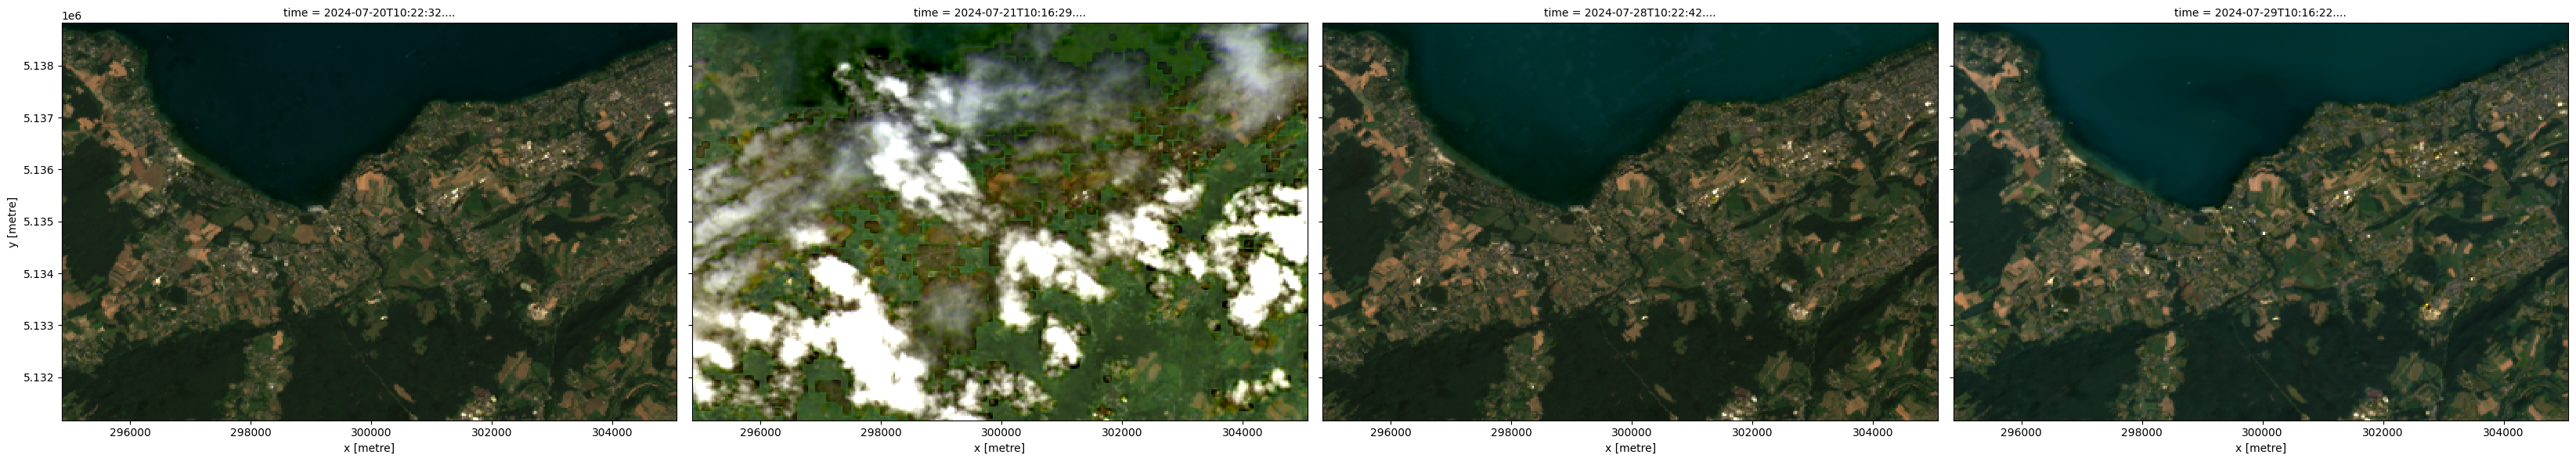

In [12]:
rgb(lazy_ds, col="time", col_wrap=4, robust=True)